In [1]:
# ============================================
# CRYPTO PRICE DIRECTION PREDICTION
# BINARY CLASSIFICATION (UP / DOWN)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("✅ Libraries loaded!")

✅ Libraries loaded!


✅ Data loaded: (730, 28)

✅ Binary target created!
   Rows: 730 → 730

📊 Class distribution:
   UP   (1): 361 (49.5%)
   DOWN (0): 369 (50.5%)

📊 Class distribution per coin:
   BITCOIN: UP=48.8% | DOWN=51.2%
   ETHEREUM: UP=50.1% | DOWN=49.9%


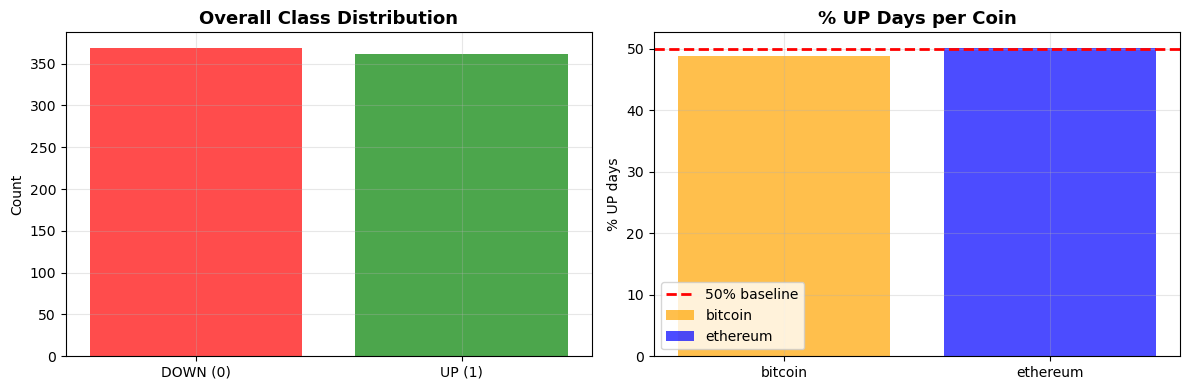

In [2]:
# ============================================
# 2. LOAD DATA & CREATE TARGET
# ============================================

df = pd.read_csv(
    "../data/processed/crypto_clean_2026-02-11.csv",
    parse_dates=["timestamp"]
)
df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)

print(f"✅ Data loaded: {df.shape}")

# ── Create Binary Target ──
# 1 = price goes UP tomorrow
# 0 = price goes DOWN tomorrow
df["target"] = (
    df.groupby("coin")["log_return_1d"]
    .shift(-1) > 0
).astype(int)

# Drop last row per coin (no next day)
rows_before = len(df)
df = df.dropna(subset=["target"]).reset_index(drop=True)

print(f"\n✅ Binary target created!")
print(f"   Rows: {rows_before} → {len(df)}")
print(f"\n📊 Class distribution:")
print(f"   UP   (1): {(df['target']==1).sum()} ({(df['target']==1).mean()*100:.1f}%)")
print(f"   DOWN (0): {(df['target']==0).sum()} ({(df['target']==0).mean()*100:.1f}%)")

print(f"\n📊 Class distribution per coin:")
for coin in ["bitcoin", "ethereum"]:
    coin_df = df[df["coin"]==coin]
    up   = (coin_df["target"]==1).mean()*100
    down = (coin_df["target"]==0).mean()*100
    print(f"   {coin.upper()}: UP={up:.1f}% | DOWN={down:.1f}%")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall
axes[0].bar(["DOWN (0)", "UP (1)"],
            [( df["target"]==0).sum(),
             (df["target"]==1).sum()],
            color=["red", "green"], alpha=0.7)
axes[0].set_title("Overall Class Distribution",
                   fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

# Per coin
for coin, color in zip(["bitcoin", "ethereum"], ["orange", "blue"]):
    coin_df = df[df["coin"]==coin]
    axes[1].bar(coin,
                (coin_df["target"]==1).mean()*100,
                color=color, alpha=0.7, label=coin)
axes[1].axhline(50, color="red", linestyle="--",
                linewidth=2, label="50% baseline")
axes[1].set_title("% UP Days per Coin",
                   fontsize=13, fontweight="bold")
axes[1].set_ylabel("% UP days")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# ============================================
# 3. CREATE LAGGED FEATURES (NO DATA LEAKAGE)
# ============================================

print("="*60)
print("CREATING LAGGED FEATURES")
print("="*60)

features_to_lag = [
    "market_cap", "volume", "market_cap_rank",
    "ath", "atl",
    "volatility_7d", "volatility_14d", "rsi_14",
    "volume_to_marketcap", "circulating_supply_history",
    "distance_from_ath", "distance_from_atl",
    "ma_7", "ma_14", "ma_30",
    "price_to_ma7", "price_to_ma30",
    "macd", "macd_signal", "macd_histogram",
    "momentum_5d", "momentum_10d", "momentum_acceleration"
]

# Create lagged features per coin
for feature in features_to_lag:
    df[f"{feature}_lag1"] = df.groupby("coin")[feature].shift(1)

# Drop NaNs from lagging
lag_cols = [f"{f}_lag1" for f in features_to_lag]
rows_before = len(df)
df = df.dropna(subset=lag_cols).reset_index(drop=True)

print(f"✅ Created {len(features_to_lag)} lagged features!")
print(f"   Rows: {rows_before} → {len(df)}")

CREATING LAGGED FEATURES
✅ Created 23 lagged features!
   Rows: 730 → 728


In [4]:
# ============================================
# 4. BUILD FEATURE MATRIX
# ============================================

print("="*60)
print("FEATURE MATRIX")
print("="*60)

# Lagged features only (no leakage!)
lagged_cols = [f"{f}_lag1" for f in features_to_lag]
static_cols = ["has_max_supply"]

# Coin dummies
coin_dummies = pd.get_dummies(
    df["coin"], prefix="coin"
).astype(int)

# Build X and y
X = df[lagged_cols + static_cols].copy()
X = pd.concat([X, coin_dummies], axis=1)
y = df["target"].copy()

print(f"✅ Feature matrix created!")
print(f"   Shape: {X.shape}")
print(f"   Features: {X.shape[1]}")
print(f"   Samples: {X.shape[0]}")
print(f"\n🔍 NaN check: {X.isna().sum().sum()} NaNs")
print(f"\n🔍 Target distribution:")
print(f"   UP   (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"   DOWN (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")

FEATURE MATRIX
✅ Feature matrix created!
   Shape: (728, 26)
   Features: 26
   Samples: 728

🔍 NaN check: 0 NaNs

🔍 Target distribution:
   UP   (1): 359 (49.3%)
   DOWN (0): 369 (50.7%)


In [5]:
# ============================================
# 5. TRAIN/VAL/TEST SPLIT (TIME-AWARE)
# ============================================

print("="*60)
print("TRAIN/VAL/TEST SPLIT")
print("="*60)

train_ratio = 0.60
val_ratio   = 0.20

train_X_list, val_X_list, test_X_list = [], [], []
train_y_list, val_y_list, test_y_list = [], [], []
train_df_list, val_df_list, test_df_list = [], [], []

for coin_name in df["coin"].unique():

    coin_mask = df["coin"] == coin_name
    coin_df   = df[coin_mask].copy()
    coin_X    = X[coin_mask].copy()
    coin_y    = y[coin_mask].copy()

    n         = len(coin_df)
    train_idx = int(n * train_ratio)
    val_idx   = int(n * (train_ratio + val_ratio))

    print(f"\n📊 {coin_name.upper()}:")
    print(f"   Train: {train_idx} samples "
          f"({coin_df.iloc[0]['timestamp'].date()} → "
          f"{coin_df.iloc[train_idx-1]['timestamp'].date()})")
    print(f"   Val:   {val_idx-train_idx} samples "
          f"({coin_df.iloc[train_idx]['timestamp'].date()} → "
          f"{coin_df.iloc[val_idx-1]['timestamp'].date()})")
    print(f"   Test:  {n-val_idx} samples "
          f"({coin_df.iloc[val_idx]['timestamp'].date()} → "
          f"{coin_df.iloc[-1]['timestamp'].date()})")

    train_X_list.append(coin_X.iloc[:train_idx])
    val_X_list.append(coin_X.iloc[train_idx:val_idx])
    test_X_list.append(coin_X.iloc[val_idx:])

    train_y_list.append(coin_y.iloc[:train_idx])
    val_y_list.append(coin_y.iloc[train_idx:val_idx])
    test_y_list.append(coin_y.iloc[val_idx:])

    train_df_list.append(coin_df.iloc[:train_idx])
    val_df_list.append(coin_df.iloc[train_idx:val_idx])
    test_df_list.append(coin_df.iloc[val_idx:])

# Combine
X_train = pd.concat(train_X_list).reset_index(drop=True)
X_val   = pd.concat(val_X_list).reset_index(drop=True)
X_test  = pd.concat(test_X_list).reset_index(drop=True)

y_train = pd.concat(train_y_list).reset_index(drop=True)
y_val   = pd.concat(val_y_list).reset_index(drop=True)
y_test  = pd.concat(test_y_list).reset_index(drop=True)

train_df = pd.concat(train_df_list).reset_index(drop=True)
val_df   = pd.concat(val_df_list).reset_index(drop=True)
test_df  = pd.concat(test_df_list).reset_index(drop=True)

print(f"\n✅ FINAL SPLIT SUMMARY:")
print(f"   Train: {len(X_train)} samples")
print(f"   Val:   {len(X_val)} samples")
print(f"   Test:  {len(X_test)} samples")
print(f"   Total: {len(X_train)+len(X_val)+len(X_test)} ✓")

TRAIN/VAL/TEST SPLIT

📊 BITCOIN:
   Train: 218 samples (2025-02-13 → 2025-09-18)
   Val:   73 samples (2025-09-19 → 2025-11-30)
   Test:  73 samples (2025-12-01 → 2026-02-11)

📊 ETHEREUM:
   Train: 218 samples (2025-02-13 → 2025-09-18)
   Val:   73 samples (2025-09-19 → 2025-11-30)
   Test:  73 samples (2025-12-01 → 2026-02-11)

✅ FINAL SPLIT SUMMARY:
   Train: 436 samples
   Val:   146 samples
   Test:  146 samples
   Total: 728 ✓


In [6]:
# ============================================
# 6. FEATURE SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

print("="*60)
print("FEATURE SCALING")
print("="*60)

no_scale_cols = ["has_max_supply", "coin_bitcoin", "coin_ethereum"]
scale_cols    = [c for c in X_train.columns if c not in no_scale_cols]

scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_val_scaled[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f"✅ Scaling complete!")
print(f"   Columns scaled:    {len(scale_cols)}")
print(f"   Columns unchanged: {len(no_scale_cols)}")
print(f"\n⚠️  Scaler fitted on TRAIN only - no data leakage! ✅")

FEATURE SCALING
✅ Scaling complete!
   Columns scaled:    23
   Columns unchanged: 3

⚠️  Scaler fitted on TRAIN only - no data leakage! ✅


In [7]:
# ============================================
# 7. EVALUATION FUNCTION
# ============================================

def evaluate_classifier(y_true, y_pred, y_prob, set_name=""):
    """
    Evaluate binary classifier performance.
    
    Metrics:
    - Accuracy: % correct predictions
    - F1 Score: Balance between precision and recall
    - ROC-AUC: Ranking ability (0.5=random, 1.0=perfect)
    - Confusion Matrix: TP, TN, FP, FN breakdown
    """
    acc     = accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n📊 {set_name} Performance:")
    print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"   F1 Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")

    return {
        "accuracy":  acc,
        "f1":        f1,
        "roc_auc":   roc_auc
    }

print("✅ Evaluation function ready!")
print("\n📋 Metrics explained:")
print("   Accuracy:  % of correct UP/DOWN predictions")
print("   F1 Score:  Balance of precision & recall (0-1)")
print("   ROC-AUC:   Ranking quality (0.5=random, 1.0=perfect)")
print("   Target:    Accuracy > 55%, ROC-AUC > 0.55")

✅ Evaluation function ready!

📋 Metrics explained:
   Accuracy:  % of correct UP/DOWN predictions
   F1 Score:  Balance of precision & recall (0-1)
   ROC-AUC:   Ranking quality (0.5=random, 1.0=perfect)
   Target:    Accuracy > 55%, ROC-AUC > 0.55


In [8]:
# ============================================
# 8. TRAIN ALL CLASSIFIERS
# ============================================

print("="*60)
print("TRAINING ALL CLASSIFIERS")
print("="*60)

# ── Model Definitions ──
models = {
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.01,
        max_depth=2,
        subsample=0.6,
        colsample_bytree=0.6,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0,
        eval_metric="logloss"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features=0.6,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.01,
        max_depth=3,
        num_leaves=8,
        subsample=0.6,
        colsample_bytree=0.6,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
}

results = {}

for model_name, model in models.items():
    print(f"\n🔧 Training {model_name}...")

    # Train
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_val   = model.predict(X_val_scaled)
    y_prob_train = model.predict_proba(X_train_scaled)[:, 1]
    y_prob_val   = model.predict_proba(X_val_scaled)[:, 1]

    # Evaluate
    train_metrics = evaluate_classifier(
        y_train, y_pred_train, y_prob_train, f"{model_name} TRAIN"
    )
    val_metrics = evaluate_classifier(
        y_val, y_pred_val, y_prob_val, f"{model_name} VAL"
    )

    # Overfitting check
    gap = train_metrics["accuracy"] - val_metrics["accuracy"]
    print(f"\n   🔍 Overfitting gap: {gap*100:.2f}%")
    if gap > 0.10:
        print(f"   ⚠️  Overfitting detected!")
    elif gap > 0.05:
        print(f"   ⚠️  Slight overfitting - acceptable")
    else:
        print(f"   ✅ Good generalization!")

    results[model_name] = {
        "model":  model,
        "train":  train_metrics,
        "val":    val_metrics,
        "gap":    gap,
        "y_pred_val": y_pred_val,
        "y_prob_val": y_prob_val
    }

    print("✅ Done!")

TRAINING ALL CLASSIFIERS

🔧 Training XGBoost...

📊 XGBoost TRAIN Performance:
   Accuracy:  0.6376 (63.76%)
   F1 Score:  0.7218
   ROC-AUC:   0.7751

📊 XGBoost VAL Performance:
   Accuracy:  0.4589 (45.89%)
   F1 Score:  0.5907
   ROC-AUC:   0.5513

   🔍 Overfitting gap: 17.87%
   ⚠️  Overfitting detected!
✅ Done!

🔧 Training Random Forest...

📊 Random Forest TRAIN Performance:
   Accuracy:  0.7385 (73.85%)
   F1 Score:  0.7756
   ROC-AUC:   0.8319

📊 Random Forest VAL Performance:
   Accuracy:  0.4521 (45.21%)
   F1 Score:  0.5918
   ROC-AUC:   0.5167

   🔍 Overfitting gap: 28.65%
   ⚠️  Overfitting detected!
✅ Done!

🔧 Training LightGBM...

📊 LightGBM TRAIN Performance:
   Accuracy:  0.7064 (70.64%)
   F1 Score:  0.7630
   ROC-AUC:   0.8170

📊 LightGBM VAL Performance:
   Accuracy:  0.4863 (48.63%)
   F1 Score:  0.6114
   ROC-AUC:   0.4918

   🔍 Overfitting gap: 22.01%
   ⚠️  Overfitting detected!
✅ Done!


📊 FINAL COMPARISON - ALL CLASSIFIERS

Model                 Train Acc    Val Acc     Val F1    Val AUC      Gap
------------------------------------------------------------------------
XGBoost                  63.76%     45.89%     0.5907     0.5513   17.87% 🏆
Random Forest            73.85%     45.21%     0.5918     0.5167   28.65%
LightGBM                 70.64%     48.63%     0.6114     0.4918   22.01% 🏆

🏆 Best Model: LightGBM
   Val Accuracy: 48.63%
   Baseline:     50.00% (random guess)
   Improvement:  -1.37% over random


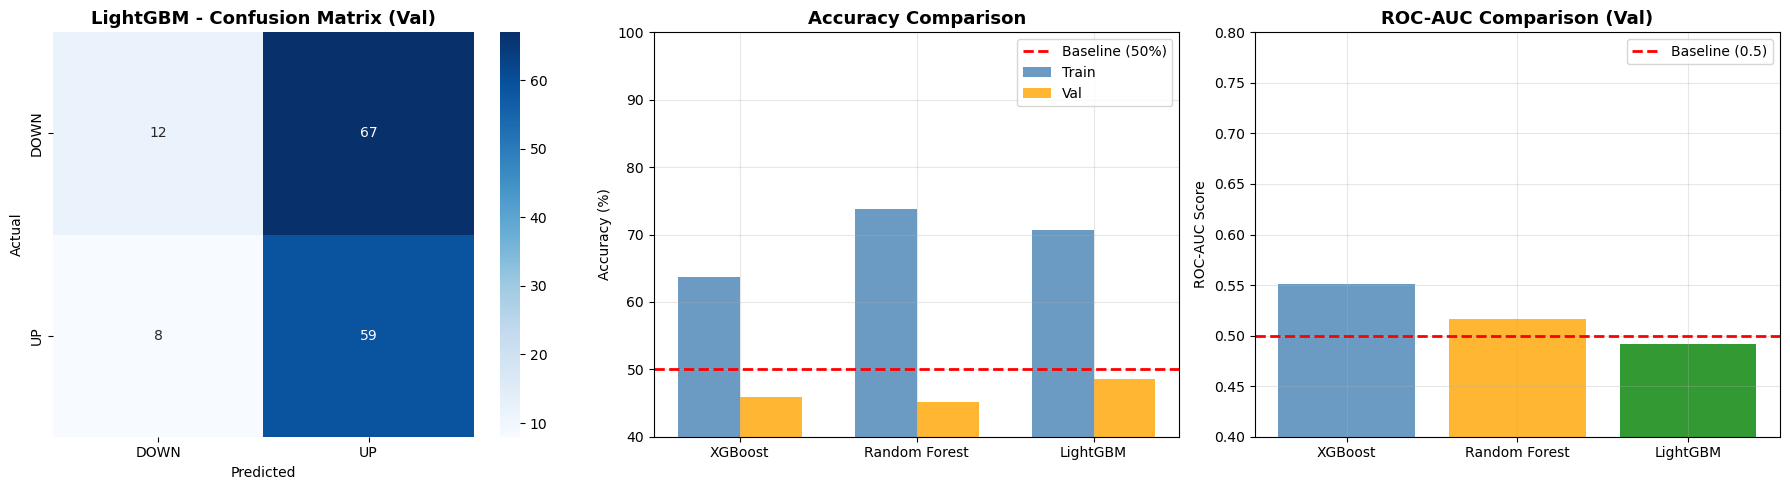


📋 Detailed Report - LightGBM:
              precision    recall  f1-score   support

    DOWN (0)       0.60      0.15      0.24        79
      UP (1)       0.47      0.88      0.61        67

    accuracy                           0.49       146
   macro avg       0.53      0.52      0.43       146
weighted avg       0.54      0.49      0.41       146



In [9]:
# ============================================
# 9. COMPARISON & VISUALIZATION
# ============================================

print("="*60)
print("📊 FINAL COMPARISON - ALL CLASSIFIERS")
print("="*60)

print(f"\n{'Model':<20} {'Train Acc':>10} {'Val Acc':>10} "
      f"{'Val F1':>10} {'Val AUC':>10} {'Gap':>8}")
print("-"*72)

best_val_acc  = 0
best_model_name = None

for name, result in results.items():
    tr_acc  = result["train"]["accuracy"]
    v_acc   = result["val"]["accuracy"]
    v_f1    = result["val"]["f1"]
    v_auc   = result["val"]["roc_auc"]
    gap     = result["gap"]

    marker = " 🏆" if v_acc > best_val_acc else ""
    print(f"{name:<20} {tr_acc*100:>9.2f}% {v_acc*100:>9.2f}% "
          f"{v_f1:>10.4f} {v_auc:>10.4f} {gap*100:>7.2f}%{marker}")

    if v_acc > best_val_acc:
        best_val_acc    = v_acc
        best_model_name = name

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Val Accuracy: {best_val_acc*100:.2f}%")
print(f"   Baseline:     50.00% (random guess)")
print(f"   Improvement:  {(best_val_acc-0.5)*100:.2f}% over random")

# ── Confusion Matrix for Best Model ──
best_result = results[best_model_name]
cm = confusion_matrix(y_val, best_result["y_pred_val"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["DOWN", "UP"],
    yticklabels=["DOWN", "UP"],
    ax=axes[0]
)
axes[0].set_title(
    f"{best_model_name} - Confusion Matrix (Val)",
    fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Plot 2: Accuracy Comparison
model_names = list(results.keys())
val_accs    = [results[m]["val"]["accuracy"]*100 for m in model_names]
train_accs  = [results[m]["train"]["accuracy"]*100 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[1].bar(x - width/2, train_accs, width,
            label="Train", color="steelblue", alpha=0.8)
axes[1].bar(x + width/2, val_accs,   width,
            label="Val",   color="orange",   alpha=0.8)
axes[1].axhline(50, color="red", linestyle="--",
                linewidth=2, label="Baseline (50%)")
axes[1].set_title("Accuracy Comparison",
                   fontsize=13, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(40, 100)

# Plot 3: ROC-AUC Comparison
val_aucs = [results[m]["val"]["roc_auc"] for m in model_names]
axes[2].bar(model_names, val_aucs,
            color=["steelblue","orange","green"], alpha=0.8)
axes[2].axhline(0.5, color="red", linestyle="--",
                linewidth=2, label="Baseline (0.5)")
axes[2].set_title("ROC-AUC Comparison (Val)",
                   fontsize=13, fontweight="bold")
axes[2].set_ylabel("ROC-AUC Score")
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_ylim(0.4, 0.8)

plt.tight_layout()
plt.show()

# ── Classification Report for Best Model ──
print(f"\n📋 Detailed Report - {best_model_name}:")
print(classification_report(
    y_val,
    best_result["y_pred_val"],
    target_names=["DOWN (0)", "UP (1)"]
))